# 02. Baseline e Modelos Clássicos (multi-horizonte h = 1, 2, 3)

Naïve, Seasonal Naïve, SES, Holt, Holt-Winters, ARIMA e SARIMA são ajustados e avaliados nos 3 horizontes, usando o esquema de walk-forward com janela expansiva do notebook 01.

In [9]:
import sys
sys.path.append("../src")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import itertools

import utils as ut

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.grid": True,
    "grid.color": "#e5e5e5", "grid.linewidth": 0.8, "font.size": 11,
})


In [10]:
train, test = ut.load_processed("../data/processed")
full = ut.make_full_series(train, test)
full_dates = full["Date"].values
full_values = full["Close"].values

origins = ut.walkforward_origins(len(train), len(test), max_h=max(ut.HORIZONS))
print(f"{len(origins)} origens de validação | horizontes: {ut.HORIZONS}")


17 origens de validação | horizontes: (1, 2, 3)


## Baselines simples

Naïve, Seasonal Naïve, SES, Holt e Holt-Winters formam o piso de comparação: nenhum deles estima uma estrutura de autocorrelação, apenas projetam nível, tendência e sazonalidade observados diretamente na série.

### Naïve e Seasonal Naïve

- Naïve: repete o último valor conhecido em todos os horizontes.
- Seasonal Naïve (m=5): repete o valor de `m` dias úteis atrás, a mesma posição no ciclo semanal.

In [11]:
rows = []
m = 5

for origin in origins:
    origin_date = full_dates[origin]
    last_value = full_values[origin]

    for h in ut.HORIZONS:
        ut.append_predictions(rows, origin_date, full_dates, full_values, origin, h, "naive", last_value)

        idx_ref = (origin + h) - m
        ut.append_predictions(rows, origin_date, full_dates, full_values, origin, h, "seasonal_naive", full_values[idx_ref])

results_baseline = pd.DataFrame(rows)
print(results_baseline.shape)
results_baseline.head(8)


(102, 6)


,origin_date,target_date,horizon,model,y_true,y_pred
0,2018-05-25,2018-05-28,1,naive,16.910000,19.799999
1,2018-05-25,2018-05-28,1,seasonal_naive,16.910000,25.049999
2,2018-05-25,2018-05-29,2,naive,19.299999,19.799999
3,2018-05-25,2018-05-29,2,seasonal_naive,19.299999,24.709999
4,2018-05-25,2018-05-30,3,naive,18.980000,19.799999
5,2018-05-25,2018-05-30,3,seasonal_naive,18.980000,23.270000
6,2018-05-28,2018-05-29,1,naive,19.299999,16.910000
7,2018-05-28,2018-05-29,1,seasonal_naive,19.299999,24.709999


### SES, Holt e Holt-Winters

Cada modelo é reajustado a cada origem, com janela expansiva (treino completo mais os dias de teste já revelados), e `forecast(3)` dá h=1, 2 e 3 de uma vez.

In [12]:
rows_suav = []

for origin in origins:
    origin_date = full_dates[origin]
    history = pd.Series(full_values[: origin + 1])
    history.index = pd.RangeIndex(len(history))

    ses = SimpleExpSmoothing(history, initialization_method="estimated").fit(optimized=True)
    ses_fc = ses.forecast(3)

    holt = Holt(history, initialization_method="estimated", damped_trend=True).fit(optimized=True)
    holt_fc = holt.forecast(3)

    hw = ExponentialSmoothing(history, trend="add", damped_trend=True, seasonal="add", seasonal_periods=5,
                               initialization_method="estimated").fit(optimized=True)
    hw_fc = hw.forecast(3)

    for i, h in enumerate(ut.HORIZONS):
        ut.append_predictions(rows_suav, origin_date, full_dates, full_values, origin, h, "ses", ses_fc.iloc[i])
        ut.append_predictions(rows_suav, origin_date, full_dates, full_values, origin, h, "holt", holt_fc.iloc[i])
        ut.append_predictions(rows_suav, origin_date, full_dates, full_values, origin, h, "holt_winters", hw_fc.iloc[i])

results_suavizacao = pd.DataFrame(rows_suav)
print(len(origins), "origens x 3 modelos x 3 horizontes =", len(results_suavizacao), "linhas")


17 origens x 3 modelos x 3 horizontes = 153 linhas


## Modelos clássicos

ARIMA e SARIMA estimam explicitamente a estrutura de autocorrelação da série, com a ordem (p, d, q) escolhida por AIC.

### ARIMA e SARIMA

A ordem (p, d, q) é escolhida uma vez por AIC no treino completo. Os coeficientes são reajustados a cada origem, mantendo essa ordem fixa.

In [13]:
y_train_only = pd.Series(train["Close"].values)
y_train_only.index = pd.RangeIndex(len(y_train_only))

best_aic, best_order = np.inf, None
for p, d, q in itertools.product(range(0, 4), [1], range(0, 4)):
    try:
        m_fit = ARIMA(y_train_only, order=(p, d, q)).fit()
        if m_fit.aic < best_aic:
            best_aic, best_order = m_fit.aic, (p, d, q)
    except Exception:
        continue
print("Melhor ordem ARIMA (por AIC, no treino completo):", best_order, f"AIC={best_aic:.2f}")

best_saic, best_sorder = np.inf, None
for P, D, Q in itertools.product(range(0, 2), [0, 1], range(0, 2)):
    try:
        m_fit = ARIMA(y_train_only, order=best_order, seasonal_order=(P, D, Q, 5)).fit()
        if m_fit.aic < best_saic:
            best_saic, best_sorder = m_fit.aic, (P, D, Q, 5)
    except Exception:
        continue
print("Melhor ordem sazonal SARIMA (m=5):", best_sorder, f"AIC={best_saic:.2f}")


Melhor ordem ARIMA (por AIC, no treino completo): (2, 1, 2) AIC=1600.34
Melhor ordem sazonal SARIMA (m=5): (0, 0, 0, 5) AIC=1600.34


In [14]:
rows_arima = []

for origin in origins:
    origin_date = full_dates[origin]
    history = pd.Series(full_values[: origin + 1])
    history.index = pd.RangeIndex(len(history))

    arima_fit = ARIMA(history, order=best_order).fit()
    arima_fc = arima_fit.forecast(3)

    sarima_fit = ARIMA(history, order=best_order, seasonal_order=best_sorder).fit()
    sarima_fc = sarima_fit.forecast(3)

    for i, h in enumerate(ut.HORIZONS):
        ut.append_predictions(rows_arima, origin_date, full_dates, full_values, origin, h, "arima", arima_fc.iloc[i])
        ut.append_predictions(rows_arima, origin_date, full_dates, full_values, origin, h, "sarima", sarima_fc.iloc[i])

results_arima = pd.DataFrame(rows_arima)
print("ARIMA e SARIMA ajustados em", len(origins), "origens.")


ARIMA e SARIMA ajustados em 17 origens.


## Consolidação dos resultados clássicos

In [15]:
results_classicos = pd.concat([results_baseline, results_suavizacao, results_arima], ignore_index=True)
results_classicos.to_csv("../results/predictions_classicos.csv", index=False)

metrics_classicos = ut.summarize_by_horizon(results_classicos)
metrics_classicos.to_csv("../results/metrics_classicos.csv", index=False)

metrics_classicos.pivot(index="model", columns="horizon", values="MAPE").round(2)


horizon,1,2,3
model,,,
arima,5.23,5.49,4.94
holt,5.11,5.12,4.41
holt_winters,5.33,5.57,5.02
naive,5.25,5.42,5.22
sarima,5.23,5.49,4.94
seasonal_naive,13.55,10.72,9.13
ses,5.24,5.38,5.18


### Erro (MAPE) por horizonte, modelos clássicos

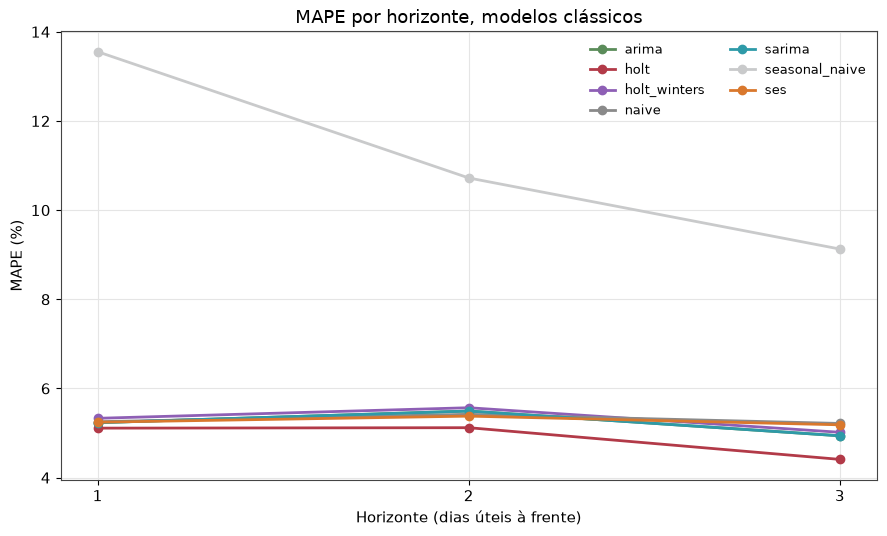

In [16]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for model, g in metrics_classicos.groupby("model"):
    g = g.sort_values("horizon")
    ax.plot(g["horizon"], g["MAPE"], marker="o", color=ut.PALETTE.get(model, "#666666"), label=model, linewidth=2)
ax.set_xticks(ut.HORIZONS)
ax.set_xlabel("Horizonte (dias úteis à frente)")
ax.set_ylabel("MAPE (%)")
ax.set_title("MAPE por horizonte, modelos clássicos")
ax.legend(frameon=False, ncol=2, fontsize=9)
fig.tight_layout()
plt.show()


O Seasonal Naïve foi o pior modelo em todos os horizontes, com erro quase o dobro dos demais, porque assume um padrão semanal que a série não tem.

Holt apresentou o melhor desempenho nos 3 horizontes.

O Holt vence porque soma um pouco de tendência amortecida ao último preço, captando o movimento recente sem exagerar (como Holt-Winters faz com uma sazonalidade que não existe) nem se apoiar em variáveis redundantes (como o ml_ridge).

* Naïve: repete o último valor. 
* Seasonal Naïve: repete o valor de 5 dias atrás.
*SES: acompanha apenas o nível. 
* Holt: nível + tendência. 
* Holt-Winters: nível + tendência + sazonalidade. 
* ARIMA: usa autocorrelação após diferenciação. 
* SARIMA: ARIMA + sazonalidade.